In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    
    return -np.sum(probs * np.log2(probs))

In [3]:
print(entropy(np.array([0, 0, 0])))     # should be 0
print(entropy(np.array([0, 1, 0, 1])))  # higher value

-0.0
1.0


In [4]:
def information_gain(y, y_left, y_right):
    parent_entropy = entropy(y)
    
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    
    weighted_entropy = (
        (n_left / n) * entropy(y_left) +
        (n_right / n) * entropy(y_right)
    )
    
    return parent_entropy - weighted_entropy

In [5]:
y = np.array([0, 1, 0, 1])

y_left = np.array([0, 0])
y_right = np.array([1, 1])

print(information_gain(y, y_left, y_right))  # should be high

1.0


In [6]:
def split(X, y, feature_index, threshold):
    left_mask = X[:, feature_index] < threshold
    right_mask = ~left_mask
    
    return (
        X[left_mask], y[left_mask],
        X[right_mask], y[right_mask]
    )

In [8]:
def best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None
    
    n_features = X.shape[1]
    
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        
        for threshold in thresholds:
            X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
            
            if len(y_l) == 0 or len(y_r) == 0:
                continue
            
            gain = information_gain(y, y_l, y_r)
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold

In [9]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape, y.shape)

(569, 30) (569,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [12]:
def build_tree(X, y, depth=0, max_depth=5):
    # Stop if pure or depth limit reached
    if len(np.unique(y)) == 1 or depth >= max_depth:
        return Node(value=np.bincount(y).argmax())
    
    feature, threshold = best_split(X, y)
    
    if feature is None:
        return Node(value=np.bincount(y).argmax())
    
    X_l, y_l, X_r, y_r = split(X, y, feature, threshold)
    
    left = build_tree(X_l, y_l, depth + 1, max_depth)
    right = build_tree(X_r, y_r, depth + 1, max_depth)
    
    return Node(feature, threshold, left, right)

In [13]:
def predict_single(x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] < node.threshold:
        return predict_single(x, node.left)
    else:
        return predict_single(x, node.right)

In [14]:
def predict(X, tree):
    return np.array([predict_single(x, tree) for x in X])

In [15]:
tree = build_tree(X_train, y_train, max_depth=5)

y_pred = predict(X_test, tree)

In [16]:
acc = np.sum(y_pred == y_test) / len(y_test)
print("Accuracy:", acc)

Accuracy: 0.956140350877193


In [17]:
depths = list(range(1, 11))

train_accs = []
test_accs = []

for d in depths:
    tree = build_tree(X_train, y_train, max_depth=d)
    
    y_train_pred = predict(X_train, tree)
    y_test_pred = predict(X_test, tree)
    
    train_acc = np.sum(y_train_pred == y_train) / len(y_train)
    test_acc = np.sum(y_test_pred == y_test) / len(y_test)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)

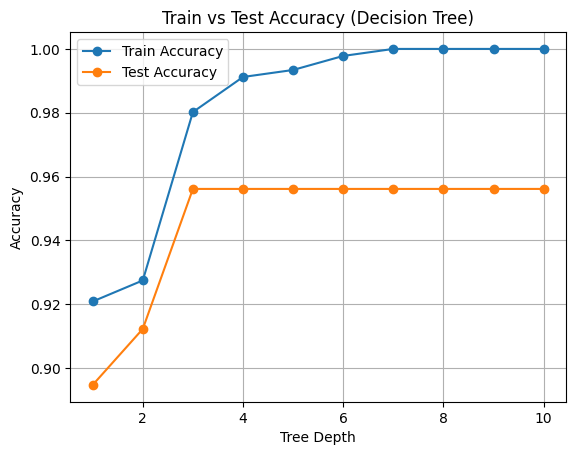

In [18]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(depths, train_accs, marker='o', label="Train Accuracy")
plt.plot(depths, test_accs, marker='o', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy (Decision Tree)")

plt.legend()
plt.grid()

plt.show()

In [19]:
def print_tree(node, depth=0):
    if node.value is not None:
        print("  " * depth + f"Leaf: Class {node.value}")
        return
    
    print("  " * depth + f"[X{node.feature} < {node.threshold}]")
    
    print_tree(node.left, depth + 1)
    print_tree(node.right, depth + 1)

In [20]:
print_tree(tree)

[X7 < 0.05182]
  [X20 < 16.89]
    [X10 < 0.645]
      [X21 < 30.25]
        Leaf: Class 1
        [X20 < 14.49]
          Leaf: Class 1
          [X0 < 13.46]
            [X1 < 30.72]
              Leaf: Class 0
              Leaf: Class 1
            Leaf: Class 1
      [X4 < 0.09387]
        Leaf: Class 1
        Leaf: Class 0
    [X1 < 16.68]
      Leaf: Class 1
      [X17 < 0.01033]
        Leaf: Class 0
        Leaf: Class 1
  [X22 < 114.6]
    [X21 < 25.84]
      [X27 < 0.1741]
        Leaf: Class 1
        Leaf: Class 0
      [X12 < 1.602]
        [X0 < 13.51]
          Leaf: Class 0
          Leaf: Class 1
        Leaf: Class 0
    Leaf: Class 0


In [21]:
def count_features(node, counts):
    if node.value is not None:
        return
    
    counts[node.feature] += 1
    
    count_features(node.left, counts)
    count_features(node.right, counts)

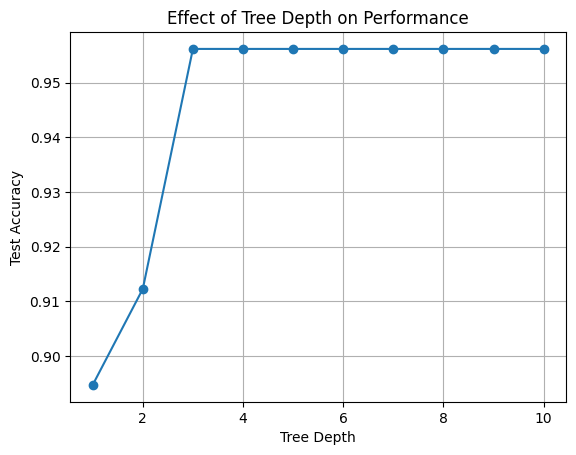

In [22]:
plt.figure()
plt.plot(depths, test_accs, marker='o')

plt.xlabel("Tree Depth")
plt.ylabel("Test Accuracy")
plt.title("Effect of Tree Depth on Performance")

plt.grid()
plt.show()